# Redes Neuronales Informadas en Física (PINNs)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana03_PINNs.ipynb)

# Oscilador armónico amortiguado

[Blog para explorar la solución al oscilador armónico amortiguado](https://beltoforion.de/en/harmonic_oscillator/)

[Basado en la explicación de Ben Moseley](https://github.com/benmoseley/harmonic-oscillator-pinn/blob/main/Harmonic%20oscillator%20PINN.ipynb)

Vamos a explorar cómo crear una PINN con `PyTorch` para el problema

$$
m \dfrac{d^2 x}{d t^2} + \mu \dfrac{d x}{d t} + kx = 0~,
$$
con condiciones iniciales

$$
x(0) = 1~~,~~\dfrac{d x}{d t} = 0~.
$$

Vamos a concentrarnos en el estado sub-atenuado donde

$$
\delta < \omega_0~,~~~~~\mathrm{with}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

En este caso la solución exacta es 

$$
x(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$

In [147]:
from PIL import Image

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

In [148]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Solución exacta")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Predicción de la red")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Datos de entrenamiento')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4, 
                    label='Puntos de colocación')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05,2)
    plt.ylim(-1.1, 1.1)
    plt.title(f"Pasos de entrenamiento: {i}",fontsize="xx-large",color="k")
    # plt.axis("off")
    
def oscillator(d, w0, x):
    """Defines the analytical solution to the 1D underdamped harmonic oscillator problem. 
    Equations taken from: https://beltoforion.de/en/harmonic_oscillator/"""
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*x)
    sin = torch.sin(phi+w*x)
    exp = torch.exp(-d*x)
    y  = exp*2*A*cos
    return y

class FCN(nn.Module):
    "Define una red neuronal completamente conectada"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_HIDDEN_LAYERS):
        super().__init__()
        
        activation = nn.Tanh
        layers = [nn.Linear(N_INPUT, N_HIDDEN), activation()]
        for _ in range(N_HIDDEN_LAYERS - 1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), activation()]
        layers += [nn.Linear(N_HIDDEN, N_OUTPUT)]
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

## Generamos datos

torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([13, 1]) torch.Size([13, 1])


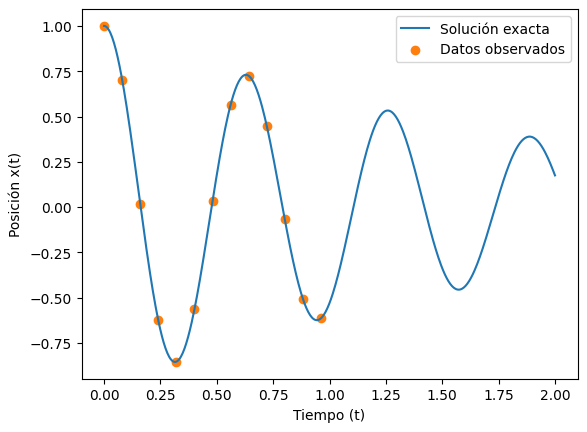

In [149]:
m = 1 # masa
k = 100 # constante del resorte
mu = 1 # coeficiente de amortiguacion

d = mu/2*m
w0 = np.sqrt(k/m)

# Solución analítica en el dominio (0,2)
t = torch.linspace(0,2,500).view(-1,1)
x = oscillator(d, w0, t).view(-1,1)
print(t.shape, x.shape)

# Elegimos puntos de entrenamiento, espaciados cada 20 puntos, para t menor a 1
t_data = t[0:241:20]
x_data = x[0:241:20]
print(t_data.shape, x_data.shape)

plt.figure()
plt.plot(t, x, label="Solución exacta")
plt.scatter(t_data, x_data, color="tab:orange", label="Datos observados")
plt.legend()
plt.xlabel("Tiempo (t)")
plt.ylabel("Posición x(t)")
plt.show()

`t_data` e `y_data` contiene 10 puntos donde hemos observado la trayectoria de este oscilador 

Iteración 0, pérdida: 0.3526


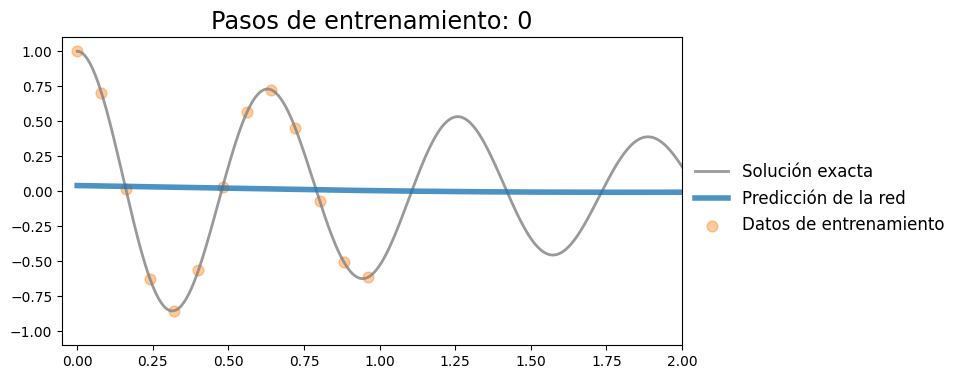

Iteración 500, pérdida: 0.0013


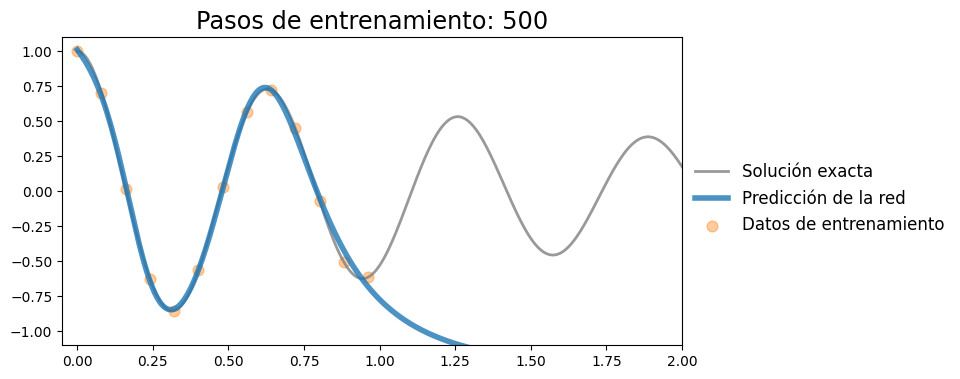

Iteración 1000, pérdida: 0.0003


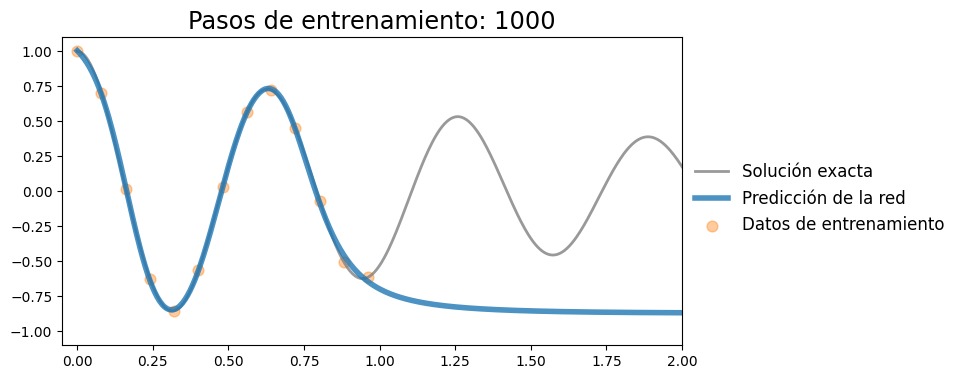

In [150]:
torch.manual_seed(2)
model = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=20, N_HIDDEN_LAYERS=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
plotting_range = range(0,1001,50)
files = []
for i in range(1001):
    optimizer.zero_grad()
    x_pred = model(t_data)
    loss = criterion(x_pred, x_data)
    loss.backward()
    optimizer.step()
    
    if i in plotting_range:
        with torch.no_grad():
            x_pred = model(t).detach()
            
        plot_result(t, x, t_data, x_data, x_pred)
        file = f"figuras/nn_{i:08d}.png"
        plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        
        if i%500 == 0:
            print(f"Iteración {i}, pérdida: {loss.item():.4f}")
            plt.show()
        else:
            plt.close("all")
            
save_gif_PIL("nn_training.gif", files, fps=5, loop=0)
        

## Implementar PINN

Agregamos la pérdida física. Para esto, vamos a fijar los puntos de colocación 

In [151]:
t_col = torch.linspace(0,2,30).unsqueeze(-1).requires_grad_()
t_col.shape

torch.Size([30, 1])

Supongamos que conocemos los parámetros del oscilador amortiguado, entonces podemos escribir el costo

Iteración 0, pérdida: 0.38400


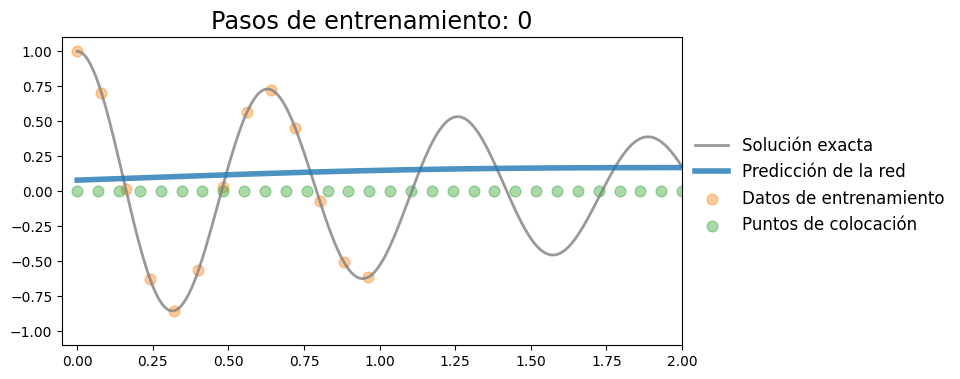

Iteración 2000, pérdida: 0.00007


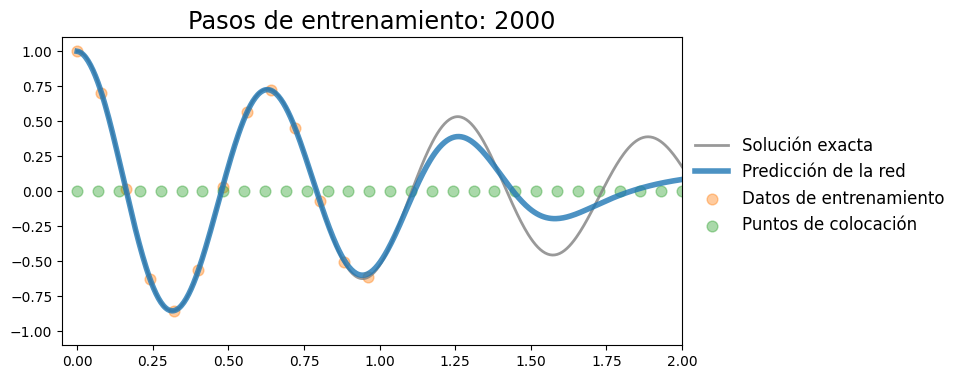

Iteración 4000, pérdida: 0.00002


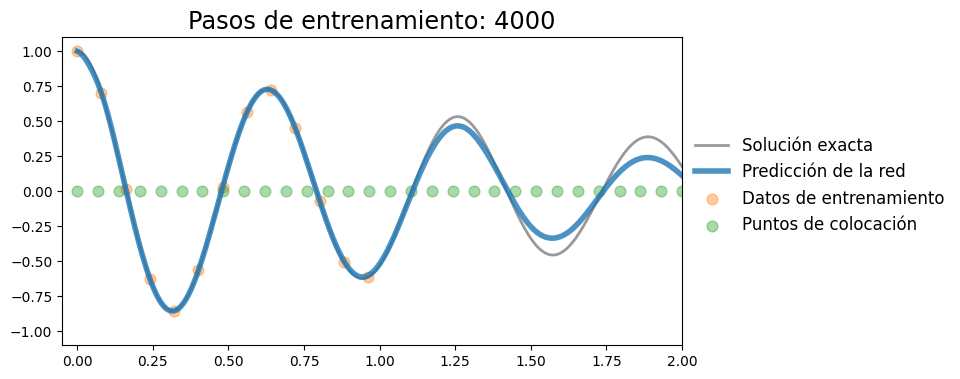

Iteración 6000, pérdida: 0.00000


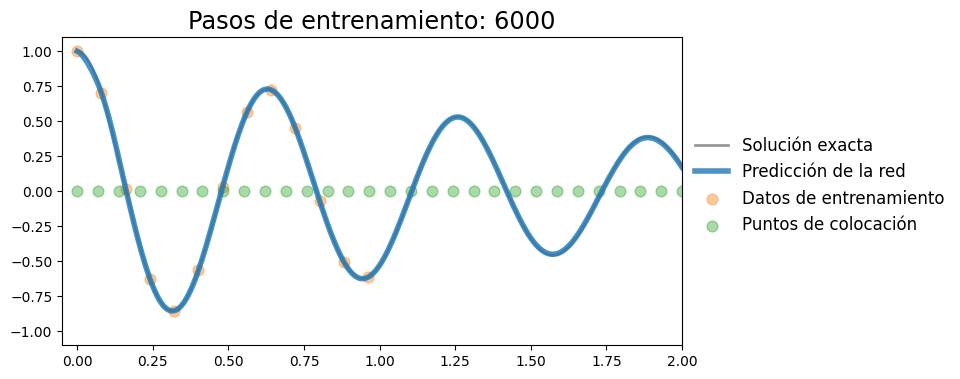

Iteración 8000, pérdida: 0.00000


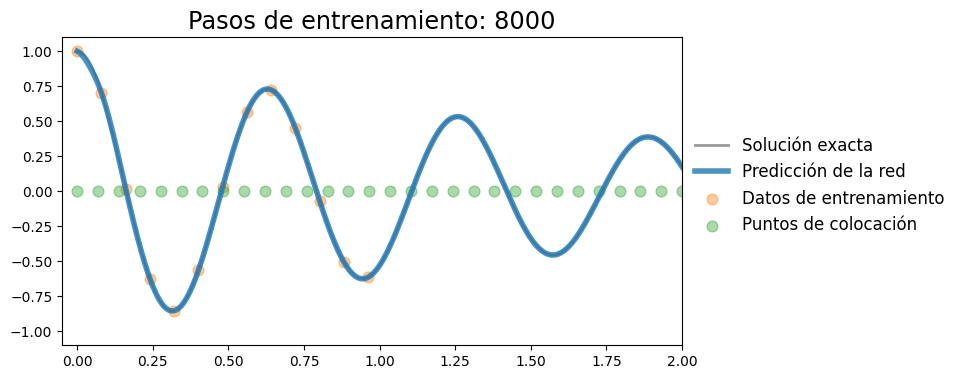

Iteración 10000, pérdida: 0.00000


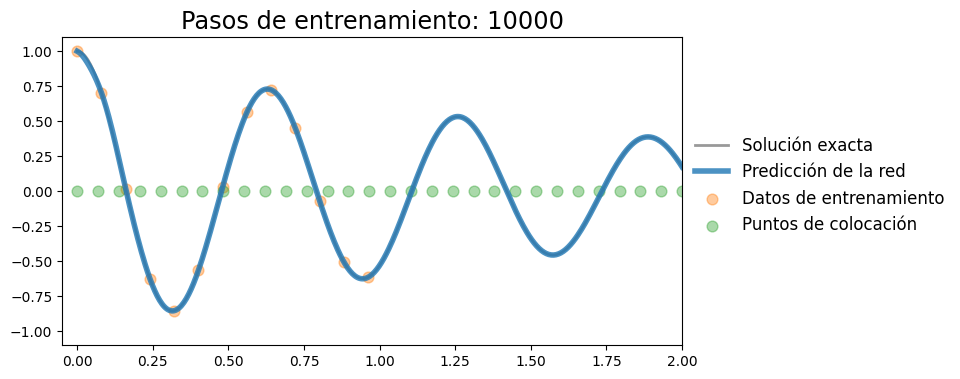

In [159]:
def loss_fisica(model, t_col, mu, k, m):
    x_pred = model(t_col)
    x_t = torch.autograd.grad(x_pred, t_col, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0] # calcula derivada primera
    x_tt = torch.autograd.grad(x_t, t_col, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]  # calcula derivada segunda
    return torch.mean((m * x_tt + mu * x_t + k * x_pred)**2)
    
torch.manual_seed(3)
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
plotting_range = range(0,10001,100)
files = []
for i in range(10001):
    optimizer.zero_grad()
    x_pred = model(t_data)
    loss = criterion(x_pred, x_data)
    loss_f = loss_fisica(model, t_col, mu, k, m)
    loss_total = loss + 1e-4*loss_f
    loss_total.backward()
    optimizer.step()
    
    if i in plotting_range:
        with torch.no_grad():
            x_pred = model(t).detach()
            
        plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
        file = f"figuras/pinn_{i:08d}.png"
        plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        
        if i%2000 == 0:
            print(f"Iteración {i}, pérdida: {loss.item():.5f}")
            plt.show()
        else:
            plt.close("all")
            
save_gif_PIL("pinn_training.gif", files, fps=5, loop=0)

## Agregar perdida de condicion inicial

(0.75, 1.1)

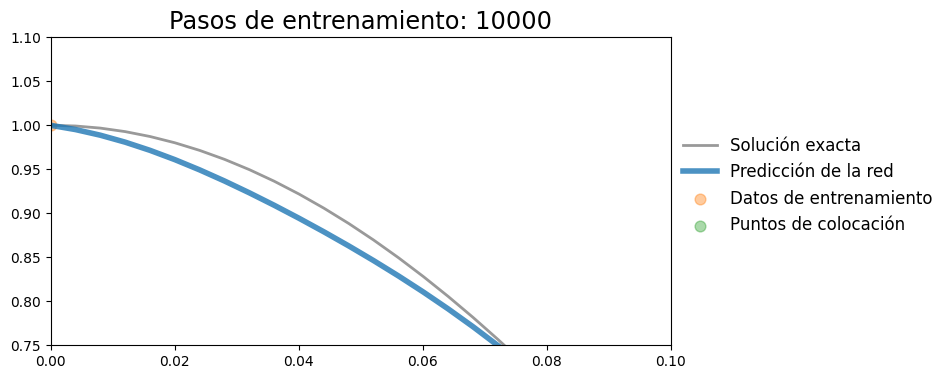

In [153]:
plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
plt.xlim(0,0.1)
plt.ylim(0.75,1.1)

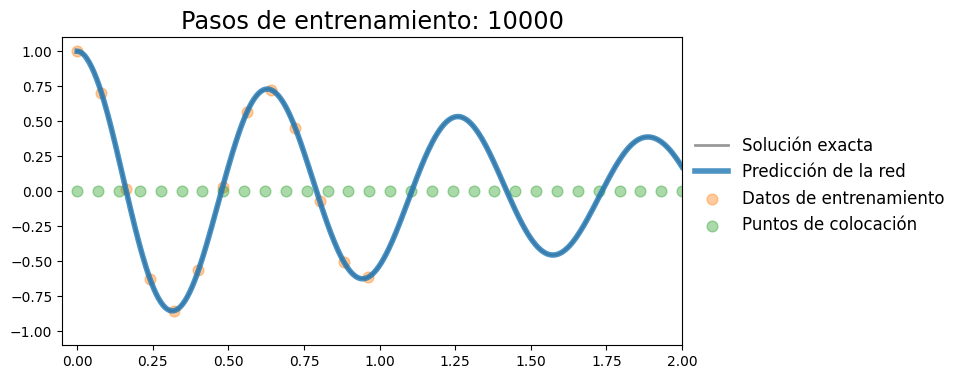

In [154]:
def loss_CI(model, t):
    x_pred = model(t)
    x_t = torch.autograd.grad(x_pred, t, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    return torch.mean((x_t)**2 + (x_pred-1)**2)

torch.manual_seed(3)
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
plotting_range = range(0,10001,2000)
files = []
for i in range(10001):
    optimizer.zero_grad()
    x_pred = model(t_data)
    loss = criterion(x_pred, x_data)
    loss_f = loss_fisica(model, t_col, mu, k, m)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    loss_ci = loss_CI(model, t0)
    loss_total = loss + 1e-4*loss_f + 1e-4*loss_ci
    loss_total.backward()
    optimizer.step()
    
with torch.no_grad():
    x_pred = model(t).detach()
    
plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
plt.show()

Vemos que la condición inicial se cumple relativamente bien, tanto en el valor como en la derivada

(0.75, 1.1)

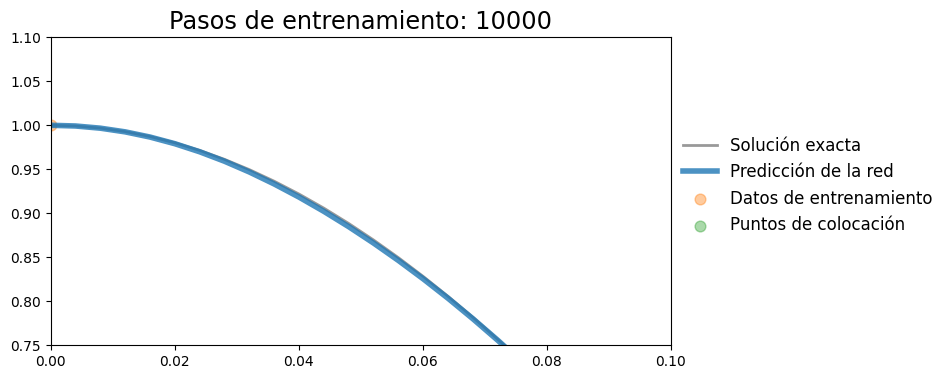

In [155]:
plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
plt.xlim(0,0.1)
plt.ylim(0.75,1.1)

## Inferencia: Deducción de parámetros

Supongamos que ahora no conocemos los parametros $m$, $k$, y $\mu$ y quisieramos encontrarlos

Iteración 0, pérdida: 0.384004, k: 80.0000, mu: 2.1269
Iteración 1000, pérdida: 0.018542, k: 80.4644, mu: 2.2170
Iteración 2000, pérdida: 0.012968, k: 81.3869, mu: 2.2617
Iteración 3000, pérdida: 0.009333, k: 82.3507, mu: 1.9060
Iteración 4000, pérdida: 0.008665, k: 83.2601, mu: 1.8954
Iteración 5000, pérdida: 0.007905, k: 84.1714, mu: 1.8859
Iteración 6000, pérdida: 0.006939, k: 85.0658, mu: 1.8481
Iteración 7000, pérdida: 0.006543, k: 85.9220, mu: 1.7386
Iteración 8000, pérdida: 0.006028, k: 86.7210, mu: 1.6134
Iteración 9000, pérdida: 0.003981, k: 87.6295, mu: 1.4964
Iteración 10000, pérdida: 0.003224, k: 88.6279, mu: 1.4095
Iteración 11000, pérdida: 0.003390, k: 89.6316, mu: 1.3307
Iteración 12000, pérdida: 0.002027, k: 90.6089, mu: 1.2616
Iteración 13000, pérdida: 0.001459, k: 91.5560, mu: 1.2014
Iteración 14000, pérdida: 0.001227, k: 92.4709, mu: 1.1522
Iteración 15000, pérdida: 0.000937, k: 93.3549, mu: 1.1121
Iteración 16000, pérdida: 0.000735, k: 94.2101, mu: 1.0782
Iteración 

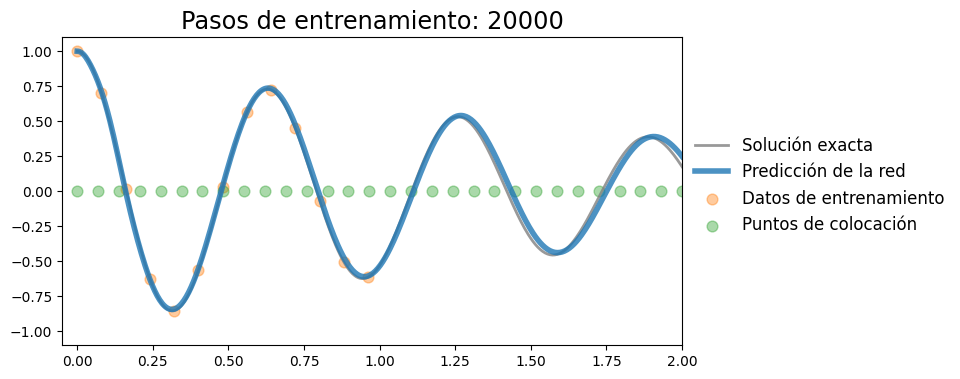

In [156]:
k_raw = torch.nn.Parameter(torch.tensor([80.0], requires_grad = True))
mu_raw = torch.nn.Parameter(torch.tensor([2.0], requires_grad = True))

def positive(x):
    return torch.nn.functional.softplus(x)



torch.manual_seed(3)
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(list(model.parameters()) + [k_raw, mu_raw], lr=0.001)
criterion = nn.MSELoss()
plotting_range = range(0,20001,2000)
files = []

for i in range(20001):
    optimizer.zero_grad()
    x_pred = model(t_data)
    loss = criterion(x_pred, x_data)
    
    k_par = positive(k_raw)
    mu_par = positive(mu_raw)
    loss_f = loss_fisica(model, t_col, mu_par, k_par, m)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    loss_ci = loss_CI(model, t0)
    loss_total = loss + 1e-3*loss_f + 1e-2*loss_ci
    loss_total.backward()
    optimizer.step()
    if i%1000==0:
        print(f"Iteración {i}, pérdida: {loss.item():.6f}, k: {k_par.item():.4f}, mu: {mu_par.item():.4f}")
    
with torch.no_grad():
    x_pred = model(t).detach()
    
plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
plt.show()

(0.75, 1.1)

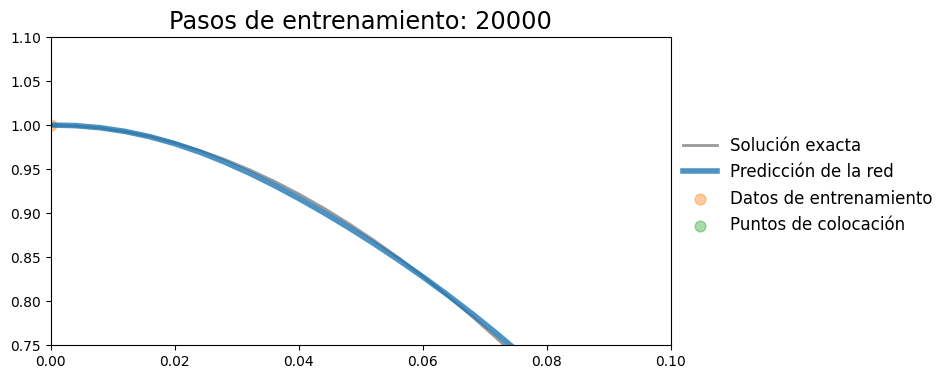

In [157]:
plot_result(t, x, t_data, x_data, x_pred, xp=t_col.detach())
plt.xlim(0,0.1)
plt.ylim(0.75,1.1)